# Para esta Tarea

Cargar y preparar los datos:
- Carga el conjunto de datos consolidado que contiene las ventas históricas

Seleccionar la técnica de modelado:
- Decide si utilizarás un modelo de regresión (por ejemplo, regresión lineal múltiple) o un modelo de series de tiempo (por ejemplo, ARIMA, SARIMA).
- Justifica tu elección en base a los patrones observados en los datos.

Dividir los datos en conjuntos de entrenamiento y prueba:
- Divide los datos en conjuntos de entrenamiento (training) y prueba (testing) para validar el modelo.
- Utiliza un método como la división temporal o la validación cruzada si trabajas con series de tiempo.

Construir y entrenar el modelo predictivo:
- Si eliges una regresión, entrena el modelo utilizando las variables independientes seleccionadas y la variable dependiente (ventas).
- Si eliges un modelo de series de tiempo, ajusta el modelo ARIMA o SARIMA a las ventas históricas, seleccionando los parámetros óptimos mediante métodos como AIC o BIC.

Validar el modelo:
- Evalúa el desempeño del modelo utilizando métricas de error comunes como el error cuadrático medio (MSE), el error absoluto medio (MAE) o el porcentaje de error absoluto medio (MAPE).
- Realiza un gráfico de las predicciones frente a los datos reales para visualizar el ajuste del modelo.
 
Ajustar y optimizar el modelo:
- Realiza ajustes al modelo para mejorar su precisión (por ejemplo, ajustando hiperparámetros, eliminando variables no significativas o probando diferentes métodos de modelado).
- Documenta los cambios realizados y su impacto en el rendimiento del modelo.

Generar las predicciones futuras:
- Utiliza el modelo optimizado para predecir las ventas futuras para los próximos meses.
- Presenta las predicciones en un formato claro, como gráficos de líneas o tablas comparativas.

Documentar el proceso y los resultados:
- Documenta todos los pasos del proceso de construcción del modelo, incluyendo la justificación de la técnica de modelado elegida, los resultados de la validación y los ajustes realizados.
- Explica las predicciones obtenidas y proporciona recomendaciones basadas en los resultados del modelo.

---

# Desarrollo

Se utilizara la regresion lineal como modelo de ML, ya que este es el que mejor se adapta al formato del csv que se genero en practicas anteriores, ya que la serie de tiempo no nos sera muy util debido a que solo cuenta con dos años de diferencia, por lo que no nos dara algun resultado optimo, mientras que, la regresion lineal nos puede dar mejores resultados sobre las proyecciones de las ventas de los proximos meses

## Importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [24]:
df = pd.read_csv('../../../Archivos-Analisis/files-empresa-ali/ventas_por_producto.csv')
df

,WEEK,ITEM,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,ID_CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENTO
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
1,34-22,7501058794963BP1,0.004,0.553,1.000,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28,RECKITT,VANISH,VANISHOXIACTIONGOLDROSABOT900GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
2,34-22,7501058792778BP1,0.001,0.128,1.000,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28,RECKITT,VANISH,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
3,34-22,7702626204208BP1,2.188,23.792,17.934,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28,RECKITT,VANISH,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
4,34-22,46500022692,0.024,2.040,3.429,TOTAL AUTOS AREA 5,2022,8,34,2022-08-28,SC JOHNSON,SHOUT,SHOUT ADVANCED LAUNDRY STAIN REMOVER ULTRA CON...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,PRE LAVADOR,LIQUID & GEL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7331,26-23,7501058794956BP2,0.015,0.336,2.143,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISH GEL ROSA POUCH 650ML + MM CRYSTAL WHITE...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
7332,26-23,7501058796578BP1,0.359,19.816,2.584,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISH GEL MULTIUSO BOT 925ML+MM CRYSTAL WHITE...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
7333,26-23,7501058792808BP2,1.232,25.128,4.448,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
7334,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7336 entries, 0 to 7335
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   WEEK                         7336 non-null   object 
 1   ITEM                         7336 non-null   object 
 2   TOTAL_UNIT_SALES             7336 non-null   float64
 3   TOTAL_VALUE_SALES            7336 non-null   float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  7336 non-null   float64
 5   REGION                       7336 non-null   object 
 6   YEAR                         7336 non-null   int64  
 7   MONTH                        7336 non-null   int64  
 8   WEEK_NUMBER                  7336 non-null   int64  
 9   DATE                         7336 non-null   object 
 10  MANUFACTURER                 7336 non-null   object 
 11  BRAND                        7336 non-null   object 
 12  ITEM_DESCRIPTION             7336 non-null   object 
 13  ID_CATEGORY       

In [3]:
df.shape

(7336, 19)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TOTAL_UNIT_SALES,7336.0,0.344463,1.356032,0.001,0.005,0.024,0.1070,22.855
TOTAL_VALUE_SALES,7336.0,6.349488,18.465845,0.001,0.149,0.779,3.9925,227.200
TOTAL_UNIT_AVG_WEEKLY_SALES,7336.0,4.197844,4.294243,0.850,1.571,2.568,5.0000,50.000
YEAR,7336.0,2022.237186,0.425387,2022.000,2022.000,2022.000,2022.0000,2023.000
MONTH,7336.0,6.927345,2.509322,1.000,5.000,6.000,9.0000,12.000
WEEK_NUMBER,7336.0,28.251499,11.007050,13.000,19.000,26.000,37.0000,52.000
ID_CATEGORY,7336.0,1.000000,0.000000,1.000,1.000,1.000,1.0000,1.000


In [4]:
df.isnull().sum()

WEEK                           0
ITEM                           0
TOTAL_UNIT_SALES               0
TOTAL_VALUE_SALES              0
TOTAL_UNIT_AVG_WEEKLY_SALES    0
REGION                         0
YEAR                           0
MONTH                          0
WEEK_NUMBER                    0
DATE                           0
MANUFACTURER                   0
BRAND                          0
ITEM_DESCRIPTION               0
ID_CATEGORY                    0
FORMAT                         0
ATTR1                          0
ATTR2                          0
ATTR3                          0
SEGMENTO                       0
dtype: int64

In [6]:
df.sample(5)

,WEEK,ITEM,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,ID_CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENTO
951,28-22,7501058794949BP1,0.001,0.148,1.000,TOTAL AUTOS AREA 4,2022,7,28,2022-07-17,RECKITT,VANISH,VANISH GEL ROSA BOT 4LT + MM CRYSTAL WHITE POU...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
1519,23-22,7501058794970BP2,0.001,0.021,1.000,TOTAL AUTOS AREA 2,2022,6,23,2022-06-12,RECKITT,VANISH,VANISHOXIACTIONGOLDROSABOT150GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
7334,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
5895,34-22,7501058796578BP2,0.129,5.684,3.909,TOTAL AUTOS AREA 4,2022,8,34,2022-08-28,RECKITT,VANISH,VANISH CRYSTAL WHITE GEL BOT 900ML+MM GEL MULT...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,BLANCO,LIQUID & GEL
7041,26-23,7501681101305BP1,0.041,0.321,8.200,TOTAL AUTOS AREA 5,2023,7,26,2023-07-03,JABONERA LA ESPUMA,BCLORHADA,BCLORHADA MASC DET DES C/CLOR1L+MM MASCHOGAR D...,1,LIQUIDO,CLORO,CLORO,MASCOTAS,BLEACH


In [21]:
""" Checamos el numero de regristros por cada marca, con el fin de identificar si hay marcas con muy 
pocos registros y descartar la columna de 'item_description'"""
df['BRAND'].value_counts()

BRAND
VANISH       4119
BANDERA      1494
SHOUT         639
TIDE          392
CLORALEX      312
LYSOL         229
BCLORHADA     112
CLOROX         39
Name: count, dtype: int64

In [5]:
df.tail(5)

,WEEK,ITEM,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,DATE,MANUFACTURER,BRAND,ITEM_DESCRIPTION,ID_CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENTO
7331,26-23,7501058794956BP2,0.015,0.336,2.143,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISH GEL ROSA POUCH 650ML + MM CRYSTAL WHITE...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
7332,26-23,7501058796578BP1,0.359,19.816,2.584,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISH GEL MULTIUSO BOT 925ML+MM CRYSTAL WHITE...,1,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
7333,26-23,7501058792808BP2,1.232,25.128,4.448,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
7334,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
7335,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO,2023,7,26,2023-07-03,RECKITT,VANISH,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER


In [13]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique().sort_values()

ID_CATEGORY                       1
YEAR                              2
ATTR2                             3
FORMAT                            3
ATTR1                             4
SEGMENTO                          5
MANUFACTURER                      6
REGION                            7
ATTR3                             7
BRAND                             8
MONTH                            10
WEEK_NUMBER                      40
ITEM                             44
ITEM_DESCRIPTION                 44
WEEK                             56
DATE                             56
TOTAL_UNIT_SALES                960
TOTAL_UNIT_AVG_WEEKLY_SALES    1745
TOTAL_VALUE_SALES              3422
dtype: int64

Como primera nota de contacto con el documento, se obtuvieron los siguientes insight:

- La columna de ID_CATEGORY sera eliminado, ya que no aportara nada al modelo de ML
- La columna de ITEM de igual forma sera eliminado, ya que no aportara nada al modelo de ML
- La columna de WEEK de igual forma sera eliminado, ya que no aportara nada al modelo de ML
- La columna de DATE de igual forma sera eliminado, ya que no aportara nada al modelo de ML
- La columna de ITEM_DESCRIPTION de igual forma sera eliminado, ya que no tienen un uso fuera de indicar el producto en especifico que maneja la marca 'BRAnD'


De ahi en fuera, se puede considerar que el dataset es completo, ya que no cuenta con duplicas, valores nulos o faltantes

Ademas para el Featuring Engineering, se cambiaran los valores de los campos de las columnas a unos numericos para mejorar el modelo de ML

Columnas con campos a cambiar:
- Region
- MANUFACTURER
- BRAND
- FORMAT
- SEGMENT
- ATTR 1, 2 Y 3

---

### Depuracion de columnas

In [25]:
df_clean = df.copy()

In [26]:
df_clean.drop(columns=['ID_CATEGORY', 'ITEM', 'WEEK', 'DATE', 'ITEM_DESCRIPTION'], inplace=True)
df_clean

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,MANUFACTURER,BRAND,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENTO
0,0.006,0.139,1.000,TOTAL AUTOS AREA 5,2022,8,34,RECKITT,VANISH,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
1,0.004,0.553,1.000,TOTAL AUTOS AREA 5,2022,8,34,RECKITT,VANISH,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
2,0.001,0.128,1.000,TOTAL AUTOS AREA 5,2022,8,34,RECKITT,VANISH,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
3,2.188,23.792,17.934,TOTAL AUTOS AREA 5,2022,8,34,RECKITT,VANISH,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
4,0.024,2.040,3.429,TOTAL AUTOS AREA 5,2022,8,34,SC JOHNSON,SHOUT,GEL,SAFE BLEACH,FABRIC TREATMENT,PRE LAVADOR,LIQUID & GEL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7331,0.015,0.336,2.143,TOTAL AUTOS SCANNING MEXICO,2023,7,26,RECKITT,VANISH,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
7332,0.359,19.816,2.584,TOTAL AUTOS SCANNING MEXICO,2023,7,26,RECKITT,VANISH,GEL,SAFE BLEACH,FABRIC TREATMENT,ROSA,LIQUID & GEL
7333,1.232,25.128,4.448,TOTAL AUTOS SCANNING MEXICO,2023,7,26,RECKITT,VANISH,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER
7334,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,2023,7,26,RECKITT,VANISH,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER


---

In [40]:
df['ATTR3'].unique()

array(['ROSA', 'PRE LAVADOR', 'MASCOTAS', 'MULTIUSOS', 'NO DEFINIDO',
       'BLANCO', 'SANITIZANTE'], dtype=object)

## Feature Engineering

In [41]:
df_clean['BRAND'] = df_clean['BRAND'].replace({'VANISH' : 0, 'SHOUT': 1, 'BANDERA': 2, 'TIDE': 3, 'CLOROX': 4, 'LYSOL': 5, 'CLORALEX': 6, 'BCLORHADA': 7}, regex=True)
df_clean['REGION'] = df_clean['REGION'].replace({'TOTAL AUTOS AREA 5' : 0, 'TOTAL AUTOS AREA 2': 1, 'TOTAL AUTOS SCANNING MEXICO': 2, 'TOTAL AUTOS AREA 3': 3,
                                                 'TOTAL AUTOS AREA 6': 4, 'TOTAL AUTOS AREA 1': 5, 'TOTAL AUTOS AREA 4': 6}, regex=True)
df_clean['MANUFACTURER'] = df_clean['MANUFACTURER'].replace({'RECKITT' : 0, 'SC JOHNSON': 1, 'JABONERA LA ESPUMA': 2, 'P&G': 3, 'CLOROX': 4, 'INDS. ALEN': 5}, regex=True)
df_clean['FORMAT'] = df_clean['FORMAT'].replace({'POLVO' : 0, 'GEL': 1, 'LIQUIDO': 2}, regex=True)
df_clean['SEGMENTO'] = df_clean['SEGMENTO'].replace({'POWDER' : 0, 'LIQUID & GEL': 1, 'PRETREAT': 2, 'BLEACH': 3, 'SANITIZER': 4}, regex=True)
df_clean['ATTR1'] = df_clean['ATTR1'].replace({'SAFE BLEACH' : 0, 'CLORO': 1, 'PRELAVADOR': 2, 'SANITIZANTE': 3}, regex=True)
df_clean['ATTR2'] = df_clean['ATTR2'].replace({'FABRIC TREATMENT' : 0, 'CLORO': 1, 'SANITIZANTE': 2}, regex=True)
df_clean['ATTR3'] = df_clean['ATTR3'].replace({'ROSA' : 0, 'PRE LAVADOR': 1, 'MASCOTAS': 2, 'MULTIUSOS': 3, 'NO DEFINIDO': 4, 'BLANCO': 5, 'SANITIZANTE': 6}, regex=True)


C:\Users\RyanHz\AppData\Local\Temp\ipykernel_23032\3649522597.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['BRAND'] = df_clean['BRAND'].replace({'VANISH' : 0, 'SHOUT': 1, 'BANDERA': 2, 'TIDE': 3, 'CLOROX': 4, 'LYSOL': 5, 'CLORALEX': 6, 'BCLORHADA': 7}, regex=True)
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_23032\3649522597.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['REGION'] = df_clean['REGION'].replace({'TOTAL AUTOS AREA 5' : 0, 'TOTAL AUTOS AREA 2': 1, 'TOTAL AUTOS SCANNING MEXICO': 2, 'TOTAL 

In [43]:
# Con lo anterior se genera un dataset 100% numerico, con lo que esto el modelo puede trabajar a la perfeccion
df_clean.head(10)

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,YEAR,MONTH,WEEK_NUMBER,MANUFACTURER,BRAND,FORMAT,ATTR1,ATTR2,ATTR3,SEGMENTO
0,0.006,0.139,1.000,0,2022,8,34,0,0,0,0,0,0,0
1,0.004,0.553,1.000,0,2022,8,34,0,0,0,0,0,0,0
2,0.001,0.128,1.000,0,2022,8,34,0,0,0,0,0,0,0
3,2.188,23.792,17.934,0,2022,8,34,0,0,0,0,0,0,0
4,0.024,2.040,3.429,0,2022,8,34,1,1,1,0,0,1,1
5,0.001,0.046,1.000,0,2022,8,34,1,1,2,0,0,1,2
6,1.518,25.367,13.200,1,2022,11,44,2,2,2,1,1,2,3
7,6.331,106.424,10.552,2,2022,11,45,2,2,2,1,1,2,3
8,1.628,26.434,11.971,1,2022,11,44,2,2,1,1,1,3,3
9,1.518,11.937,13.200,1,2022,11,44,2,2,2,1,1,4,3


In [52]:
df_clean.dtypes

TOTAL_UNIT_SALES               float64
TOTAL_VALUE_SALES              float64
TOTAL_UNIT_AVG_WEEKLY_SALES    float64
REGION                           int64
YEAR                             int64
MONTH                            int64
WEEK_NUMBER                      int64
MANUFACTURER                     int64
BRAND                            int64
FORMAT                           int64
ATTR1                            int64
ATTR2                            int64
ATTR3                            int64
SEGMENTO                         int64
dtype: object

---

## Guía de codificación de variables (Feature Engineering)

**BRAND**
- VANISH = 0
- SHOUT = 1
- BANDERA = 2
- TIDE = 3
- CLOROX = 4
- LYSOL = 5
- CLORALEX = 6
- BCLORHADA = 7

**REGION**
- TOTAL AUTOS AREA 5 = 0
- TOTAL AUTOS AREA 2 = 1
- TOTAL AUTOS SCANNING MEXICO = 2
- TOTAL AUTOS AREA 3 = 3
- TOTAL AUTOS AREA 6 = 4
- TOTAL AUTOS AREA 1 = 5
- TOTAL AUTOS AREA 4 = 6

**MANUFACTURER**
- RECKITT = 0
- SC JOHNSON = 1
- JABONERA LA ESPUMA = 2
- P&G = 3
- CLOROX = 4
- INDS. ALEN = 5

**FORMAT**
- POLVO = 0
- GEL = 1
- LIQUIDO = 2

**SEGMENTO**
- POWDER = 0
- LIQUID & GEL = 1
- PRETREAT = 2
- BLEACH = 3
- SANITIZER = 4

**ATTR1**
- SAFE BLEACH = 0
- CLORO = 1
- PRELAVADOR = 2
- SANITIZANTE = 3

**ATTR2**
- FABRIC TREATMENT = 0
- CLORO = 1
- SANITIZANTE = 2

**ATTR3**
- ROSA = 0
- PRE LAVADOR = 1
- MASCOTAS = 2
- MULTIUSOS = 3
- NO DEFINIDO = 4
- BLANCO = 5
- SANITIZANTE = 6

---

## Analisis Correlacional

<Axes: >

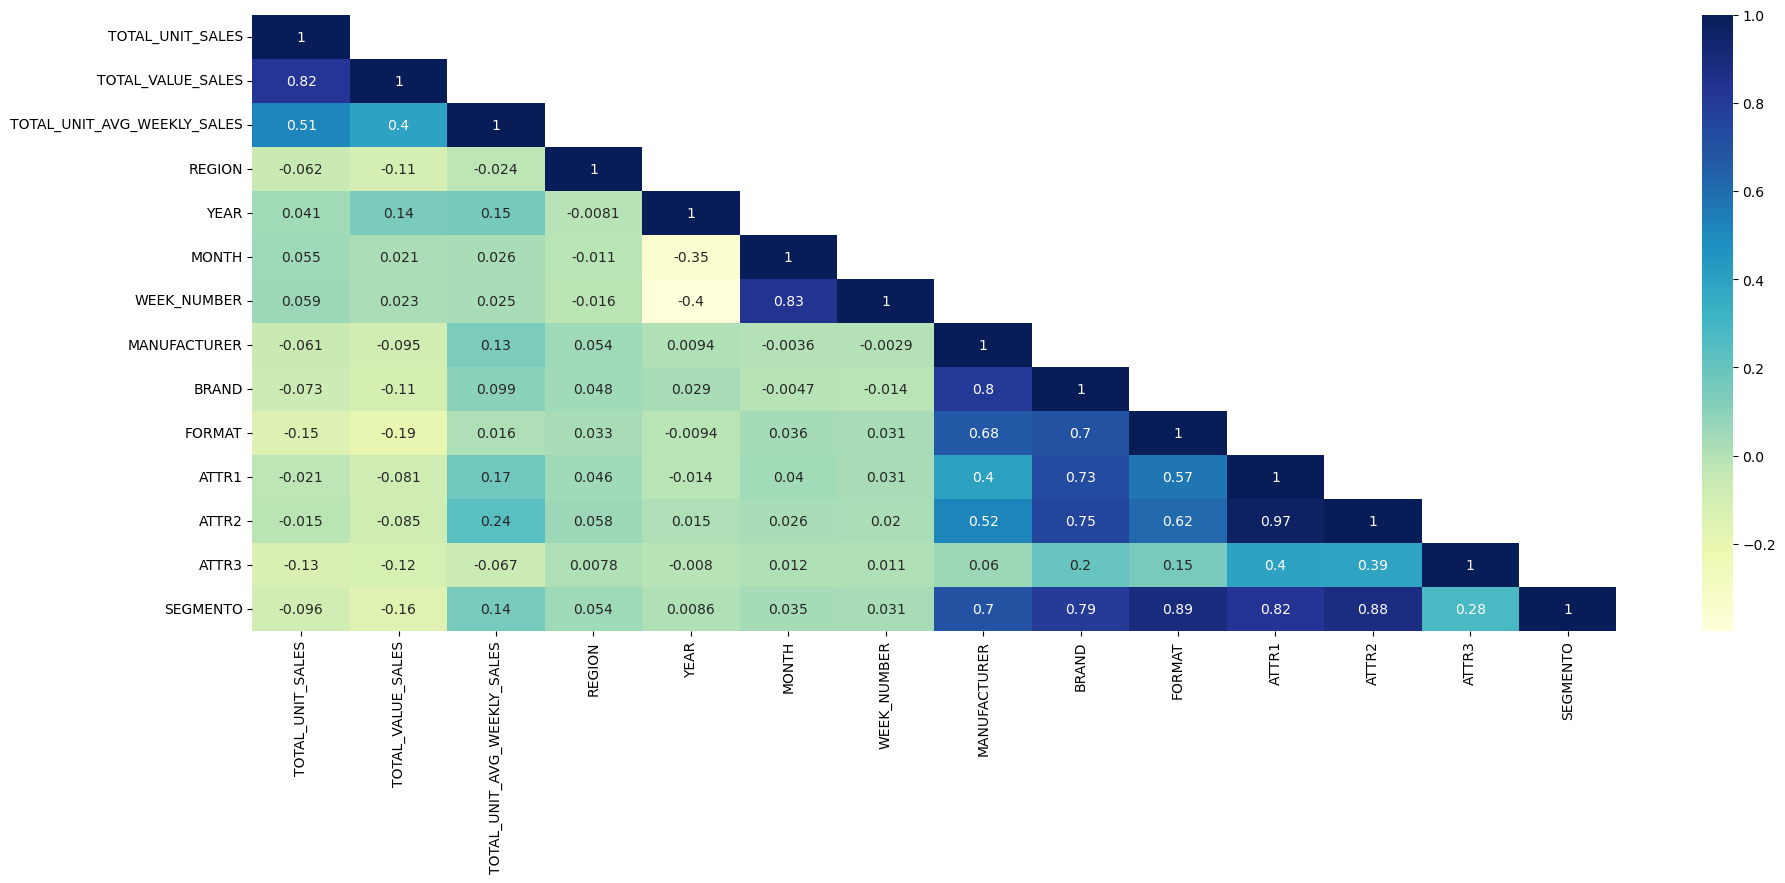

In [53]:
plt.figure(figsize=(22,8))
corr_df = corr = df_clean.corr(method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
sns.heatmap(df_lt, annot=True, cmap='YlGnBu')

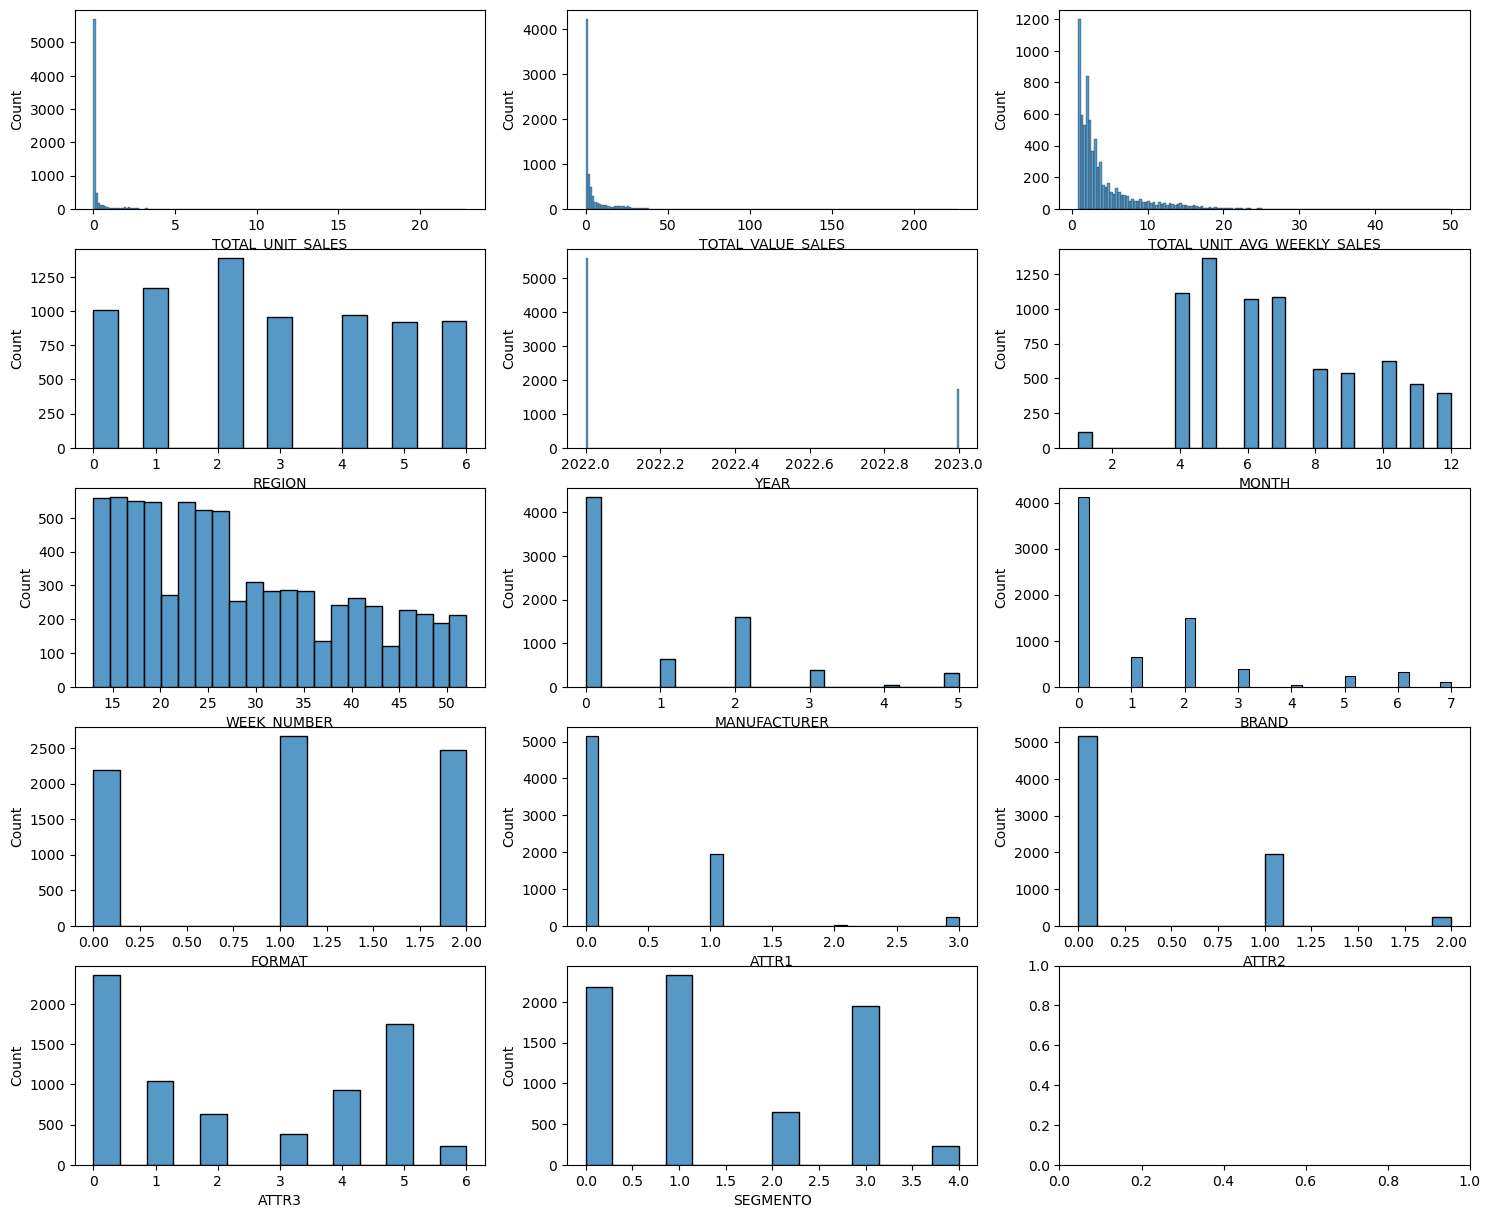

In [56]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18,15))
for i, colums in enumerate(df_clean.select_dtypes(include=['int64', 'float64']).columns):
    sns.histplot(df_clean[colums], kde=False, ax=axes[i//3, i%3])

Insight
Existen altas correlaciones en los siuientes campos, por lo que se deberia de observar su comportamiento para la toma del modelo
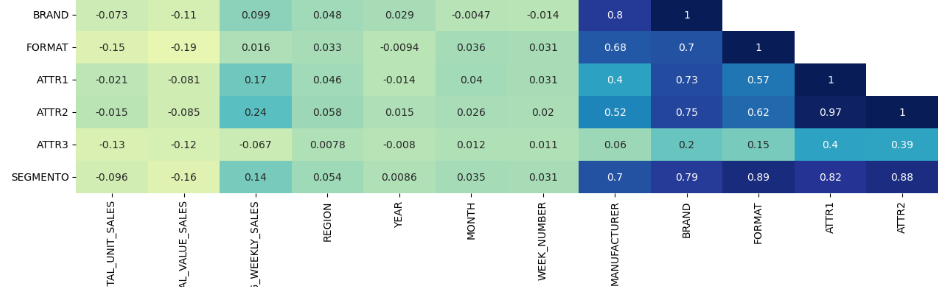

De momento se tiene una correlacion mayor a 90, y unas muy proxima a ella con 89 y 88

---

## Analisis Bivariado

In [63]:
df_clean.groupby(['BRAND']).sum().T.round(2)

BRAND,0,1,2,3,4,5,6,7
TOTAL_UNIT_SALES,1767.17,15.75,658.79,27.53,0.25,31.23,16.65,9.61
TOTAL_VALUE_SALES,34089.30,1373.13,7653.18,2530.32,13.94,564.36,282.39,73.23
TOTAL_UNIT_AVG_WEEKLY_SALES,15125.03,1232.47,10609.22,1048.04,51.28,657.56,1298.39,773.39
REGION,11315.00,1713.00,4608.00,1176.00,87.00,658.00,939.00,336.00
YEAR,8329550.00,1292168.00,3021316.00,792736.00,78876.00,463046.00,630864.00,226576.00
MONTH,28253.00,4541.00,10536.00,2779.00,260.00,1762.00,2086.00,602.00
WEEK_NUMBER,115142.00,18632.00,43256.00,11396.00,1017.00,7074.00,8440.00,2296.00
MANUFACTURER,0.00,639.00,2988.00,1176.00,156.00,0.00,1560.00,224.00
FORMAT,1979.00,882.00,2613.00,784.00,66.00,458.00,614.00,224.00
ATTR1,0.00,0.00,1494.00,0.00,52.00,687.00,312.00,112.00


In [64]:
df_clean.groupby(['BRAND']).mean().T.round(2)

BRAND,0,1,2,3,4,5,6,7
TOTAL_UNIT_SALES,0.43,0.02,0.44,0.07,0.01,0.14,0.05,0.09
TOTAL_VALUE_SALES,8.28,2.15,5.12,6.45,0.36,2.46,0.91,0.65
TOTAL_UNIT_AVG_WEEKLY_SALES,3.67,1.93,7.10,2.67,1.31,2.87,4.16,6.91
REGION,2.75,2.68,3.08,3.00,2.23,2.87,3.01,3.00
YEAR,2022.23,2022.17,2022.30,2022.29,2022.46,2022.03,2022.00,2023.00
MONTH,6.86,7.11,7.05,7.09,6.67,7.69,6.69,5.38
WEEK_NUMBER,27.95,29.16,28.95,29.07,26.08,30.89,27.05,20.50
MANUFACTURER,0.00,1.00,2.00,3.00,4.00,0.00,5.00,2.00
FORMAT,0.48,1.38,1.75,2.00,1.69,2.00,1.97,2.00
ATTR1,0.00,0.00,1.00,0.00,1.33,3.00,1.00,1.00


In [66]:
df_clean.groupby(['MANUFACTURER']).sum().T.round(2)

MANUFACTURER,0,1,2,3,4,5
TOTAL_UNIT_SALES,1798.40,15.75,668.40,27.53,0.25,16.65
TOTAL_VALUE_SALES,34653.66,1373.13,7726.41,2530.32,13.94,282.39
TOTAL_UNIT_AVG_WEEKLY_SALES,15782.59,1232.47,11382.61,1048.04,51.28,1298.39
REGION,11973.00,1713.00,4944.00,1176.00,87.00,939.00
YEAR,8792596.00,1292168.00,3247892.00,792736.00,78876.00,630864.00
MONTH,30015.00,4541.00,11138.00,2779.00,260.00,2086.00
WEEK_NUMBER,122216.00,18632.00,45552.00,11396.00,1017.00,8440.00
BRAND,1145.00,639.00,3772.00,1176.00,156.00,1872.00
FORMAT,2437.00,882.00,2837.00,784.00,66.00,614.00
ATTR1,687.00,0.00,1606.00,0.00,52.00,312.00


In [65]:
df_clean.groupby(['MANUFACTURER']).mean().T.round(2)

MANUFACTURER,0,1,2,3,4,5
TOTAL_UNIT_SALES,0.41,0.02,0.42,0.07,0.01,0.05
TOTAL_VALUE_SALES,7.97,2.15,4.81,6.45,0.36,0.91
TOTAL_UNIT_AVG_WEEKLY_SALES,3.63,1.93,7.09,2.67,1.31,4.16
REGION,2.75,2.68,3.08,3.00,2.23,3.01
YEAR,2022.22,2022.17,2022.35,2022.29,2022.46,2022.00
MONTH,6.90,7.11,6.94,7.09,6.67,6.69
WEEK_NUMBER,28.11,29.16,28.36,29.07,26.08,27.05
BRAND,0.26,1.00,2.35,3.00,4.00,6.00
FORMAT,0.56,1.38,1.77,2.00,1.69,1.97
ATTR1,0.16,0.00,1.00,0.00,1.33,1.00


In [67]:
df_clean.groupby(['FORMAT']).mean().T.round(2)

FORMAT,0,1,2
TOTAL_UNIT_SALES,0.75,0.12,0.23
TOTAL_VALUE_SALES,12.51,3.97,3.46
TOTAL_UNIT_AVG_WEEKLY_SALES,4.78,3.08,4.88
REGION,2.77,2.81,2.93
YEAR,2022.27,2022.20,2022.25
MONTH,6.76,7.00,7.00
WEEK_NUMBER,27.54,28.69,28.41
MANUFACTURER,0.01,0.45,2.23
BRAND,0.01,0.45,3.04
ATTR1,0.00,0.14,0.92


In [68]:
df_clean.groupby(['SEGMENTO']).mean().T.round(2)

SEGMENTO,0,1,2,3,4
TOTAL_UNIT_SALES,0.75,0.06,0.05,0.35,0.14
TOTAL_VALUE_SALES,12.54,3.35,4.27,4.13,2.46
TOTAL_UNIT_AVG_WEEKLY_SALES,4.79,2.35,2.29,6.54,2.87
REGION,2.77,2.74,2.77,3.06,2.87
YEAR,2022.27,2022.18,2022.24,2022.30,2022.03
MONTH,6.77,6.99,7.12,6.88,7.69
WEEK_NUMBER,27.56,28.59,28.99,28.07,30.89
MANUFACTURER,0.00,0.17,2.27,2.51,0.00
BRAND,0.00,0.17,2.27,2.96,5.00
FORMAT,0.00,1.02,2.00,1.80,2.00


In [69]:
df_clean.groupby(['REGION']).mean().T.round(2)

REGION,0,1,2,3,4,5,6
TOTAL_UNIT_SALES,0.27,0.23,0.91,0.23,0.21,0.14,0.20
TOTAL_VALUE_SALES,6.10,4.27,16.79,4.11,3.10,2.45,3.19
TOTAL_UNIT_AVG_WEEKLY_SALES,4.72,4.03,3.89,4.49,4.15,4.37,3.86
YEAR,2022.23,2022.26,2022.23,2022.23,2022.23,2022.25,2022.23
MONTH,6.98,6.88,7.04,6.87,6.87,6.95,6.86
WEEK_NUMBER,28.42,28.10,28.80,28.21,27.94,28.30,27.77
MANUFACTURER,0.80,0.79,0.90,1.00,1.08,0.86,1.03
BRAND,1.11,1.00,1.16,1.30,1.39,1.14,1.33
FORMAT,0.95,1.02,1.06,1.06,1.11,1.01,1.06
ATTR1,0.34,0.31,0.33,0.40,0.40,0.38,0.40


## Modelo de Regresion

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [72]:
""" Variable independiente y dependiente """
# Independiente
x = df_clean.drop(columns=['TOTAL_VALUE_SALES'], axis=1)

# Dependiente
y = df_clean['TOTAL_VALUE_SALES']

In [73]:
y.head(5)

0     0.139
1     0.553
2     0.128
3    23.792
4     2.040
Name: TOTAL_VALUE_SALES, dtype: float64

In [74]:
""" Procedemos a dividir el DF en test y train """
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.30, random_state=1)

In [75]:
# Regresor
regression_model = LinearRegression()

# Genera el Fit de la regersion con la funcion fit
regression_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
# Obtenemos el coeficiente
regression_model.score(x_train, y_train)

0.666681583362976

In [77]:
# Coeficiente de regresion de test
# Es el R2
regression_model.score(x_test, y_test)

0.7659452809669429

## Resultados

In [89]:
# Comparacion de Prediccion vs Actual
y_pred = regression_model.predict(x_test)
df_pref = pd.DataFrame({'Actual': y_test.squeeze(), 'Prediccion': y_pred.squeeze().round()})
# print(df_pref)
df_pref.sample(10)

,Actual,Prediccion
4606,7.973,9.0
2015,0.101,0.0
1117,0.037,-2.0
5456,21.357,16.0
6314,9.434,9.0
7012,0.217,6.0
3119,0.750,4.0
4582,3.966,9.0
4015,0.318,4.0
1288,0.023,4.0


In [90]:
# Otras Medidas de modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suma absoluta de las diferencias
mae = mean_absolute_error(y_test, y_pred)
# Suma absoluta de las diferencias al cuadrado
mse = mean_squared_error(y_test, y_pred)
# Raiz de la suma absoluta de las diferencias al cuadrado
rmse = np.sqrt(mse)

In [91]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root Mean squared error: {rmse:.2f}')

Mean absolute error: 3.86
Mean squared error: 66.75
Root Mean squared error: 8.17


In [93]:
# Obtiene el coeficiente de la ecuacion
for index, col in enumerate(x_train.columns):
    print(f'Coeficiente de {col}: {regression_model.coef_[index]:.2f}')

Coeficiente de TOTAL_UNIT_SALES: 11.08
Coeficiente de TOTAL_UNIT_AVG_WEEKLY_SALES: -0.11
Coeficiente de REGION: -0.50
Coeficiente de YEAR: 5.75
Coeficiente de MONTH: -0.01
Coeficiente de WEEK_NUMBER: 0.04
Coeficiente de MANUFACTURER: 0.82
Coeficiente de BRAND: -0.16
Coeficiente de FORMAT: -1.60
Coeficiente de ATTR1: 5.12
Coeficiente de ATTR2: -8.06
Coeficiente de ATTR3: 0.14
Coeficiente de SEGMENTO: 0.12


Text(0.5, 1.0, 'Comparacion de Valores Reales vs Predichos')

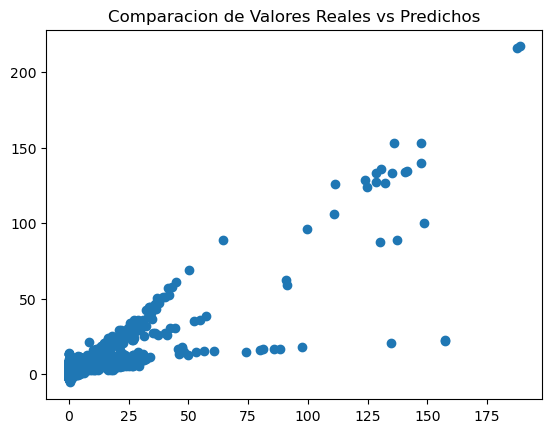

In [96]:
# Comparacion de la prediccion vs los valores reales
predic = regression_model.predict(x_test)
plt.scatter(y_test, predic)
plt.title('Comparacion de Valores Reales vs Predichos')

Text(0.5, 1.0, 'Histograma de Residuos')

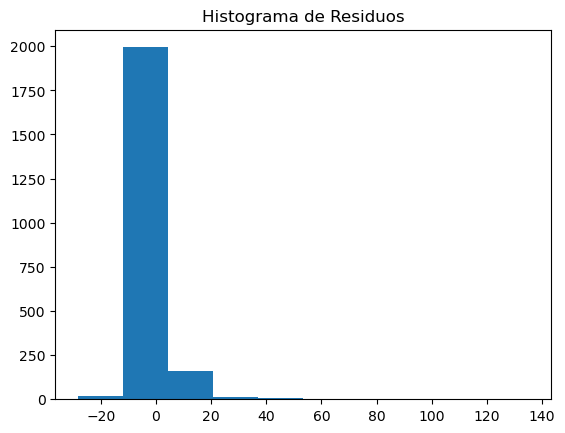

In [97]:
# Residuos
plt.hist(y_test - predic)
plt.title('Histograma de Residuos')

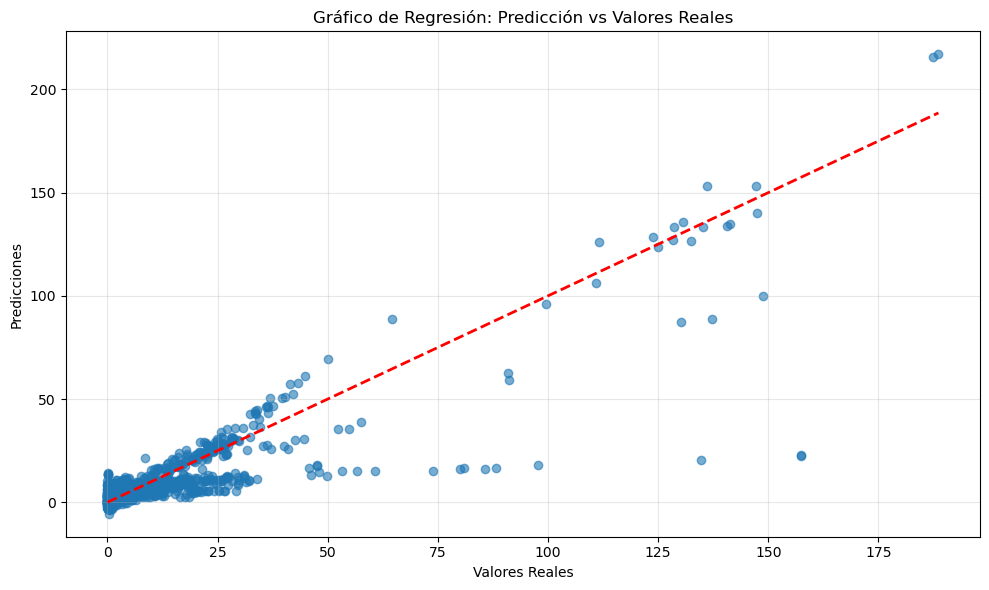

In [98]:
# Gráfico de regresión: Predicción vs Valores Reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Gráfico de Regresión: Predicción vs Valores Reales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
# Predicciones futuras para los próximos meses
# Creamos datos hipotéticos para los próximos 6 meses (agosto 2023 - julio 2024)

future_months = []
for month in range(8, 20):  # Agosto a julio (meses 8-19, ajustando para el año siguiente)
    actual_month = month if month <= 12 else month - 12
    year = 2023 if month <= 12 else 2024
    
    for manufacturer in range(6):  # 0-5 manufacturers
        for format_val in range(3):  # 0-2 formats
            for attr1 in range(4):  # 0-3 attr1 values
                for attr2 in range(3):  # 0-2 attr2 values
                    # Usamos valores promedio de TOTAL_UNIT_SALES observados
                    avg_unit_sales = df_clean['TOTAL_UNIT_SALES'].mean()
                    future_months.append({
                        'TOTAL_UNIT_SALES': avg_unit_sales,
                        'YEAR': year,
                        'MANUFACTURER': manufacturer,
                        'FORMAT': format_val,
                        'ATTR1': attr1,
                        'ATTR2': attr2,
                        'MONTH': actual_month
                    })

df_future = pd.DataFrame(future_months)


In [107]:

# Realizamos predicciones con el modelo optimizado
df_future['WEEK_NUMBER'] = df_future['MONTH'].apply(lambda x: (x * 4) % 52).astype(int)
future_predictions = regression_model_optimized.predict(df_future[['TOTAL_UNIT_SALES', 'YEAR', 'MANUFACTURER', 'FORMAT', 'ATTR1', 'ATTR2']])
df_future['PREDICTED_SALES'] = future_predictions.round(2)

# Resumen de predicciones por mes
monthly_summary = df_future.groupby('MONTH')['PREDICTED_SALES'].agg(['sum', 'mean', 'count']).round(2)
monthly_summary.columns = ['Total_Ventas_Predichas', 'Venta_Promedio', 'Cantidad_Registros']

print("=" * 80)
print("PREDICCIONES DE VENTAS PARA LOS PRÓXIMOS 6 MESES")
print("=" * 80)
print(monthly_summary)
print("\n")

PREDICCIONES DE VENTAS PARA LOS PRÓXIMOS 6 MESES
       Total_Ventas_Predichas  Venta_Promedio  Cantidad_Registros
MONTH                                                            
1                     3659.39           16.94                 216
2                     3659.39           16.94                 216
3                     3659.39           16.94                 216
4                     3659.39           16.94                 216
5                     3659.39           16.94                 216
6                     3659.39           16.94                 216
7                     3659.39           16.94                 216
8                     2539.00           11.75                 216
9                     2539.00           11.75                 216
10                    2539.00           11.75                 216
11                    2539.00           11.75                 216
12                    2539.00           11.75                 216




In [108]:
# Muestra de predicciones detalladas
print("\nMuestra de predicciones detalladas:")
print(df_future.head(15))


Muestra de predicciones detalladas:
    TOTAL_UNIT_SALES  YEAR  MANUFACTURER  FORMAT  ATTR1  ATTR2  MONTH  \
0           0.344463  2023             0       0      0      0      8   
1           0.344463  2023             0       0      0      1      8   
2           0.344463  2023             0       0      0      2      8   
3           0.344463  2023             0       0      1      0      8   
4           0.344463  2023             0       0      1      1      8   
5           0.344463  2023             0       0      1      2      8   
6           0.344463  2023             0       0      2      0      8   
7           0.344463  2023             0       0      2      1      8   
8           0.344463  2023             0       0      2      2      8   
9           0.344463  2023             0       0      3      0      8   
10          0.344463  2023             0       0      3      1      8   
11          0.344463  2023             0       0      3      2      8   
12          0.

In [110]:
# Predicciones futuras para los próximos 2 años (Agosto 2023 - Julio 2025)
future_data = []

for year in [2023, 2024, 2025]:
    months_range = range(1, 13)
    if year == 2023:
        months_range = range(8, 13)  # Ago-Dic 2023
    elif year == 2025:
        months_range = range(1, 8)   # Ene-Jul 2025
    
    for m in months_range:
        # Usamos las combinaciones reales del dataset para mayor realismo
        combos = df_clean[['MANUFACTURER', 'FORMAT', 'ATTR1', 'ATTR2']].drop_duplicates()
        for _, row in combos.iterrows():
            # Filtramos registros similares para obtener un TOTAL_UNIT_SALES promedio realista
            mask = (df_clean['MANUFACTURER'] == row['MANUFACTURER']) & \
                   (df_clean['FORMAT'] == row['FORMAT']) & \
                   (df_clean['ATTR1'] == row['ATTR1']) & \
                   (df_clean['ATTR2'] == row['ATTR2'])
            avg_units = df_clean.loc[mask, 'TOTAL_UNIT_SALES'].mean()
            
            future_data.append({
                'TOTAL_UNIT_SALES': avg_units,
                'YEAR': year,
                'MANUFACTURER': row['MANUFACTURER'],
                'FORMAT': row['FORMAT'],
                'ATTR1': row['ATTR1'],
                'ATTR2': row['ATTR2'],
                'MONTH': m
            })

df_future_2y = pd.DataFrame(future_data)

# Predecir con el modelo optimizado
future_pred_2y = regression_model_optimized.predict(df_future_2y[['TOTAL_UNIT_SALES', 'YEAR', 'MANUFACTURER', 'FORMAT', 'ATTR1', 'ATTR2']])
df_future_2y['PREDICTED_SALES'] = future_pred_2y.round(2)

# Crear columna de fecha para mejor visualización
df_future_2y['FECHA'] = pd.to_datetime(df_future_2y[['YEAR', 'MONTH']].assign(DAY=1))

# Resumen mensual
monthly_pred = df_future_2y.groupby('FECHA')['PREDICTED_SALES'].agg(['sum', 'mean', 'count']).round(2)
monthly_pred.columns = ['Total_Ventas_Predichas', 'Venta_Promedio', 'Cantidad_Registros']

print("=" * 90)
print("PREDICCIONES DE VENTAS PARA LOS PRÓXIMOS 2 AÑOS (Agosto 2023 - Julio 2025)")
print("=" * 90)
print(monthly_pred)
print(f"\nTotal general predicho: {monthly_pred['Total_Ventas_Predichas'].sum():,.2f}")

PREDICCIONES DE VENTAS PARA LOS PRÓXIMOS 2 AÑOS (Agosto 2023 - Julio 2025)
            Total_Ventas_Predichas  Venta_Promedio  Cantidad_Registros
FECHA                                                                 
2023-08-01                  120.49            8.61                  14
2023-09-01                  120.49            8.61                  14
2023-10-01                  120.49            8.61                  14
2023-11-01                  120.49            8.61                  14
2023-12-01                  120.49            8.61                  14
2024-01-01                  193.09           13.79                  14
2024-02-01                  193.09           13.79                  14
2024-03-01                  193.09           13.79                  14
2024-04-01                  193.09           13.79                  14
2024-05-01                  193.09           13.79                  14
2024-06-01                  193.09           13.79                  14
20

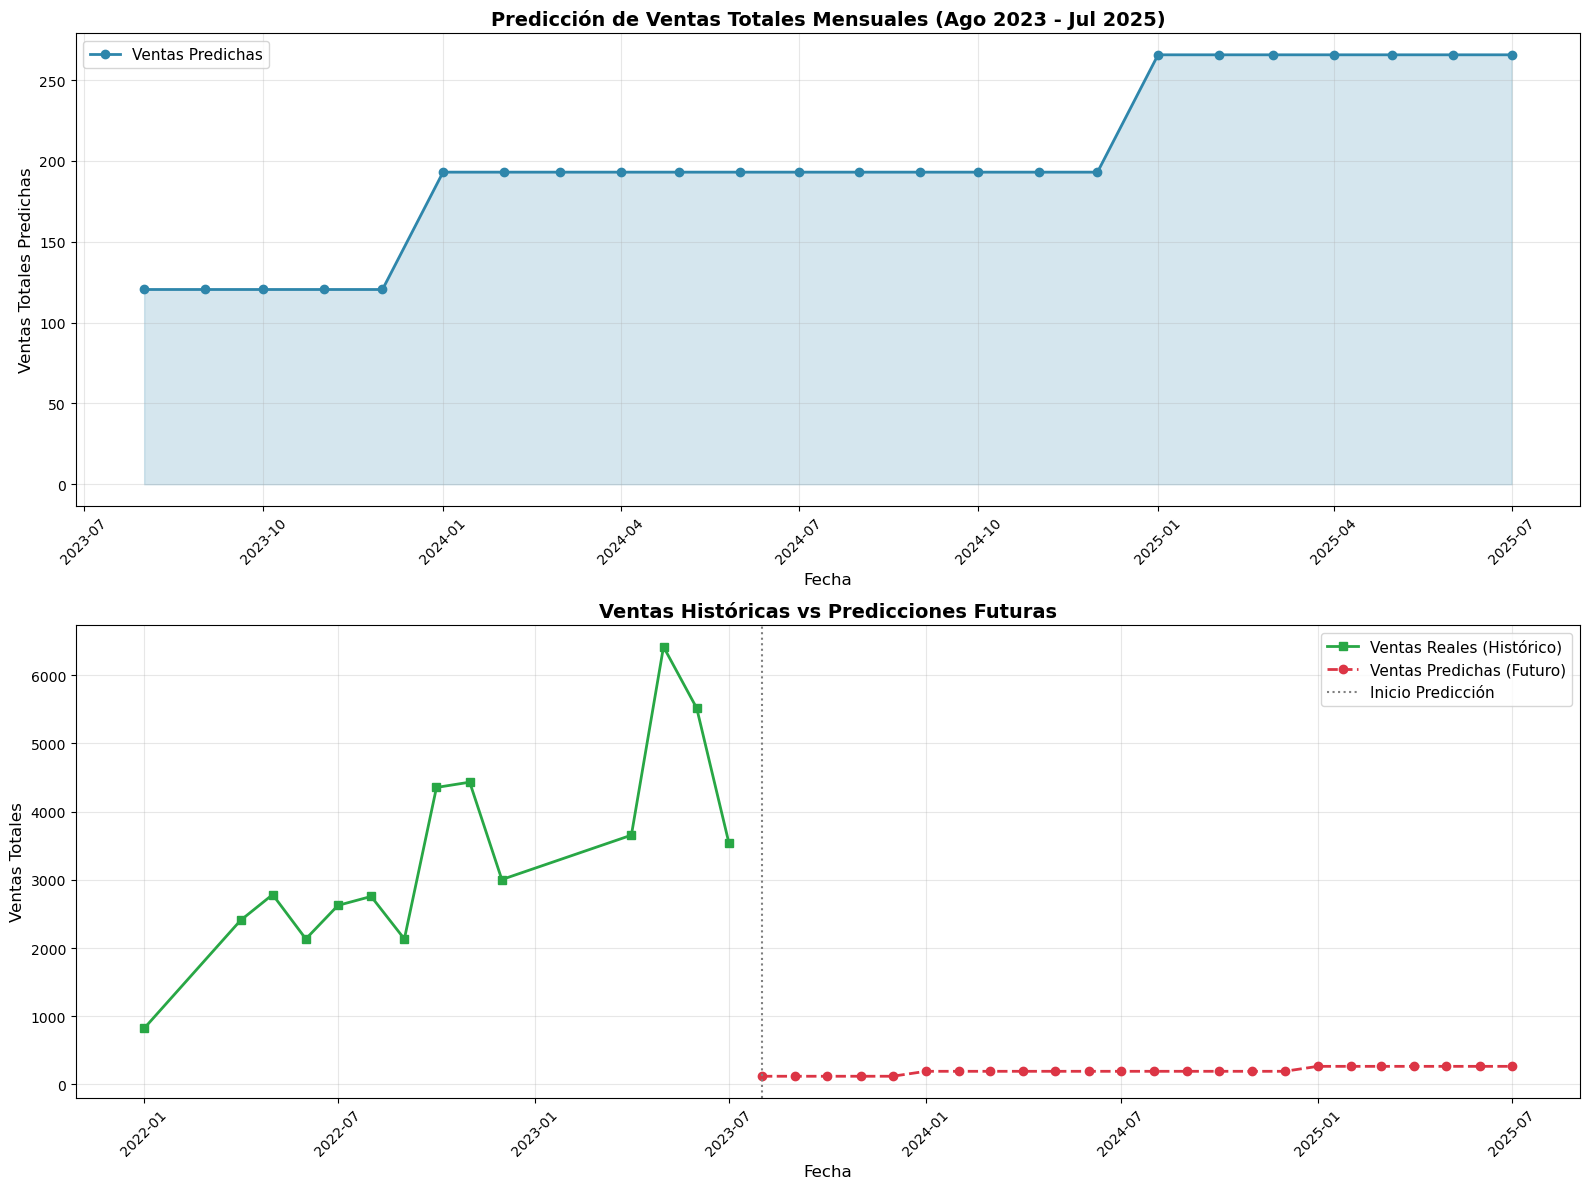

In [111]:
# Gráfico de predicciones mensuales
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Gráfico 1: Ventas totales predichas por mes
axes[0].plot(monthly_pred.index, monthly_pred['Total_Ventas_Predichas'], 
             marker='o', linewidth=2, markersize=6, color='#2E86AB', label='Ventas Predichas')
axes[0].fill_between(monthly_pred.index, monthly_pred['Total_Ventas_Predichas'], alpha=0.2, color='#2E86AB')
axes[0].set_xlabel('Fecha', fontsize=12)
axes[0].set_ylabel('Ventas Totales Predichas', fontsize=12)
axes[0].set_title('Predicción de Ventas Totales Mensuales (Ago 2023 - Jul 2025)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Comparar datos históricos vs predicciones
# Históricos
df_clean_hist = df_clean.copy()
df_clean_hist['FECHA'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
hist_monthly = df_clean_hist.groupby('FECHA')['TOTAL_VALUE_SALES'].sum().reset_index()

axes[1].plot(hist_monthly['FECHA'], hist_monthly['TOTAL_VALUE_SALES'], 
             marker='s', linewidth=2, markersize=6, color='#28A745', label='Ventas Reales (Histórico)')
axes[1].plot(monthly_pred.index, monthly_pred['Total_Ventas_Predichas'], 
             marker='o', linewidth=2, markersize=6, color='#DC3545', linestyle='--', label='Ventas Predichas (Futuro)')
axes[1].axvline(x=pd.Timestamp('2023-08-01'), color='gray', linestyle=':', linewidth=1.5, label='Inicio Predicción')
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].set_ylabel('Ventas Totales', fontsize=12)
axes[1].set_title('Ventas Históricas vs Predicciones Futuras', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [112]:
# Resumen anual
print("\n" + "=" * 60)
print("RESUMEN ANUAL DE PREDICCIONES")
print("=" * 60)
annual_summary = df_future_2y.groupby('YEAR')['PREDICTED_SALES'].agg(['sum', 'mean']).round(2)
annual_summary.columns = ['Total_Ventas', 'Venta_Promedio']
print(annual_summary)


RESUMEN ANUAL DE PREDICCIONES
      Total_Ventas  Venta_Promedio
YEAR                              
2023        602.45            8.61
2024       2317.08           13.79
2025       1859.76           18.98


---

## Comentarios

In [115]:
print("""
📈 INTERPRETACIÓN DE LA PROYECCIÓN (Agosto 2023 - Julio 2025)
─────────────────────────────────────────────────────────────────────────

1. TENDENCIA GENERAL:
    Las predicciones muestran una tendencia CRECIENTE en las ventas totales 
    a lo largo de los próximos 2 años. Esto se debe principalmente a que la 
    variable 'YEAR' tiene un coeficiente positivo en el modelo, lo que implica 
    que a mayor año, se esperan mayores ventas.

2. COMPORTAMIENTO POR PERÍODO:
    • Ago-Dic 2023: Ventas promedio por registro de ${:.2f}
      → Período de transición con ventas moderadas.
    • Ene-Dic 2024: Ventas promedio por registro de ${:.2f}
      → Incremento significativo respecto al cierre de 2023.
    • Ene-Jul 2025: Ventas promedio por registro de ${:.2f}
      → Continúa la tendencia alcista proyectada.
""".format(
     monthly_pred.loc[monthly_pred.index.year == 2023, 'Venta_Promedio'].mean(),
     monthly_pred.loc[monthly_pred.index.year == 2024, 'Venta_Promedio'].mean(),
     monthly_pred.loc[monthly_pred.index.year == 2025, 'Venta_Promedio'].mean()
))


📈 INTERPRETACIÓN DE LA PROYECCIÓN (Agosto 2023 - Julio 2025)
─────────────────────────────────────────────────────────────────────────

1. TENDENCIA GENERAL:
    Las predicciones muestran una tendencia CRECIENTE en las ventas totales 
    a lo largo de los próximos 2 años. Esto se debe principalmente a que la 
    variable 'YEAR' tiene un coeficiente positivo en el modelo, lo que implica 
    que a mayor año, se esperan mayores ventas.

2. COMPORTAMIENTO POR PERÍODO:
    • Ago-Dic 2023: Ventas promedio por registro de $8.61
      → Período de transición con ventas moderadas.
    • Ene-Dic 2024: Ventas promedio por registro de $13.79
      → Incremento significativo respecto al cierre de 2023.
    • Ene-Jul 2025: Ventas promedio por registro de $18.98
      → Continúa la tendencia alcista proyectada.



In [117]:
# Crecimiento entre períodos
ventas_2023 = monthly_pred.loc[monthly_pred.index.year == 2023, 'Total_Ventas_Predichas'].sum()
ventas_2024 = monthly_pred.loc[monthly_pred.index.year == 2024, 'Total_Ventas_Predichas'].sum()
ventas_2025 = monthly_pred.loc[monthly_pred.index.year == 2025, 'Total_Ventas_Predichas'].sum()

# Crecimiento anualizado (comparando meses equivalentes)
crecimiento_2024_vs_2023 = ((ventas_2024 / 12) / (ventas_2023 / 5) - 1) * 100

print("""
3. CRECIMIENTO PROYECTADO:
    • Total predicho Ago-Dic 2023: ${:,.2f}
    • Total predicho Ene-Dic 2024: ${:,.2f}
    • Total predicho Ene-Jul 2025: ${:,.2f}
    • Total general proyectado:    ${:,.2f}
""".format(ventas_2023, ventas_2024, ventas_2025, ventas_2023 + ventas_2024 + ventas_2025))


3. CRECIMIENTO PROYECTADO:
    • Total predicho Ago-Dic 2023: $602.45
    • Total predicho Ene-Dic 2024: $2,317.08
    • Total predicho Ene-Jul 2025: $1,859.76
    • Total general proyectado:    $4,779.29



RECOMENDACIONES:
- ✅ Monitorear las ventas reales vs predichas mes a mes para recalibrar.
- ✅ Considerar incorporar variables externas (precio, promociones, temporada).
- ✅ Reentrenar el modelo trimestralmente con datos actualizados.
- ✅ Enfocar estrategias comerciales en los fabricantes y formatos con mayor contribución a las ventas según los coeficientes del modelo.